<a href="https://colab.research.google.com/github/samnne/onc-bloom/blob/main/onc_bloom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**When the Ocean Blooms:** _Visualizing the Chlorophyll Levels in the Strait of Georgia._





Every Spring, there is a sudden rush of vibrant green that fills the waters in British Columbia.


Why does this happen?


Because Phytoplankton finally get to flourish after facing harsh winters. The reason why these little buggers are important is that they help provide a vital food source to shrimp, all the way to Humpback whales. In this workshop, we will use Python to 'visualize' this bloom using ONC's underwater sensors.

















##1. **The Environment**

_NOTE: Any level of Python experience (or basic programming experience) can follow along with this tutorial._





The notebook will take an approach to understanding ONC's Data API using `pandas`, `matplotlib` with `.pyplot`, and `onc` to visualize, understand, and analyze the ocean.





To follow along, we need to install ONC's client library and import the libraries highlighted below.



In [62]:
# Install the ONC Library (-q: Silent Mode)
!pip install onc -q


from onc.onc import ONC
import pandas
import matplotlib.pyplot as plt



- `from onc.onc import ONC`: This is ONC's Class that we can use to find our required data.

- `matplotlib.pyplot as plt`: Matplotlib is the tool that we will use to plot our data throughout this notebook

- `import pandas`: Pandas is a data science tool that can clean and build data models.



From going through this notebook we will use each of these tools to visualize the **Bloom!**

**1.1 Extra Configuration**

Extra configuration we NEED is the API Token attainable by creating an account with ONC. Think of your API Token as a personal master key that an application (ONC) provides to you, which gives you access to certain tools that the app decides.

To attain this token, create (or log in) an account on ONC’s [Registration Page.](https://data.oceannetworks.ca/Profile) Once registerd, you’ll be redirected to your [Profile Page](https://data.oceannetworks.ca/Profile) and head to the tab that says **Web Services API** and click **‘Copy Token’**.

Below are images of the Register Process and Where to Find your Token.

NOTE: for the purposes of this notebook, this access token will NOT work for you, please register your own to follow along.

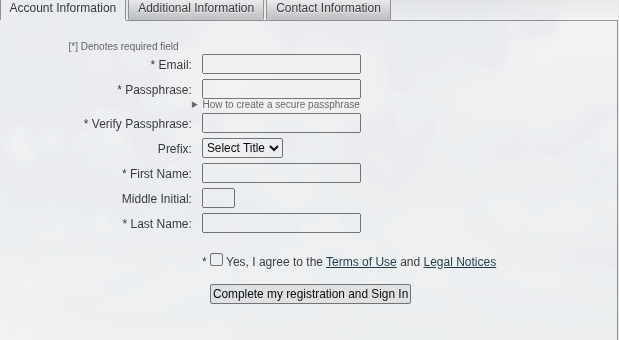

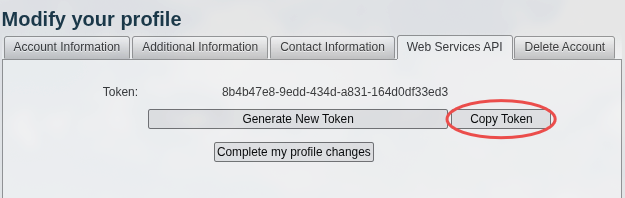

Now let's configure our **API** Token.

- Click on the key in the sidebar of this notebook in Google Colab.
- Click on Add new secret
- Name your token to be 'ONC_TOKEN'
- Paste the copied token value into the value input box

Voila! That's all you need and we can continue.

In [63]:
# This step is to inject your API Token into Google Colab
from google.colab import userdata

# Initialize the token to the Global Value
ONC_TOKEN = userdata.get('ONC_TOKEN')


# Start the ONC Client
onc: ONC = ONC(ONC_TOKEN)

##**2 Finding the Right Data**.

Before we further analyze, we gotta find the location where these phytoplankton bloom.

**2.1** **Location**

The location code we’ll need is for the Saanich Inlet and verify a device in that location tracks Chlorophyll levels. To find such a device, we have to go to the Data Search tab on the [Oceans 3.0 Data Portal](https://data.oceannetworks.ca/).



On the left navigation bar, we want to sort by location and find the Pacific->Salish Sea cell.

Then we open **Strait Of Georgia -> S.o.G VENUS**, and Click on **Fluorometer Turbidity**.

You'll see a dark pop up on the map, and under **Properties** you'll see Chlorophyll, **that is what we need!**

Since we know the Fluorometer is in Strait Of Georgia The location code can be deduced to be SCVIP.

Alternatively, we can first get locations where [deviceCode: 'WLFLNTU060901'](https://data.oceannetworks.ca/DeviceListing?DeviceId=1303)
which can be found by clicking on details in the map popup. Then looking at the ouput we can find that our needed Fluorometer has a locationCode of SCVIP, which is what we need.

Now let's go back to the python code and demonstrate this process.

In [64]:
# This is for demonstration purposes to print the object with pretty print
# to correctly show how we get the locationCode
from pprint import pprint

device_cat = onc.getLocations({
  "deviceCode": "WLFLNTU2472"
})
for cat in device_cat:
    pprint(cat)
# In the output there should be an object that has a locationCode: SCVIP

{'bbox': {'maxDepth': 65.0,
          'maxLat': 53.975165,
          'maxLon': -128.65701,
          'minDepth': 40.0,
          'minLat': 53.9734,
          'minLon': -128.657243},
 'dataSearchURL': 'https://data.oceannetworks.ca/DataSearch?location=KVIP',
 'deployments': 27,
 'depth': 45.381481,
 'description': '',
 'hasDeviceData': True,
 'hasPropertyData': False,
 'lat': 53.974701,
 'locationCode': 'KVIP',
 'locationName': 'Kitamaat Village Underwater Network',
 'lon': -128.657129}
{'bbox': {'maxDepth': 148.0,
          'maxLat': 49.080637,
          'maxLon': -123.339545,
          'minDepth': 148.0,
          'minLat': 49.080637,
          'minLon': -123.339545},
 'dataSearchURL': 'https://data.oceannetworks.ca/DataSearch?location=LSDDL.F2',
 'deployments': 1,
 'depth': 148.0,
 'description': '',
 'hasDeviceData': True,
 'hasPropertyData': False,
 'lat': 49.080637,
 'locationCode': 'LSDDL.F2',
 'locationName': 'Fluorometer 0.4 mab',
 'lon': -123.339545}
{'bbox': {'maxDepth': 331.

**2.2 Our Current Parameters**

When working with the Ocean's API. It's easier to use it by using a `params` object to send into any given method. Given what we found in *Section 2.1*, our *locationCode* is *SCVIP*, and _deviceCategoryCode_ is _FLNTU_. We also need the timeframe that the device tracked chlorophyll levels, which started around March 3rd 2024. We also need to retrieve ONC's cleaned version of the data and normalize the data in JSON.


In [69]:
params = {
    'dateFrom': '2024-03-20T16:02:37.000Z',
    "locationCode": "SCVIP",
    "rowLimit": "1000",
    "returnOptions": "normalizeJson",
    "deviceCategoryCode": "FLNTU",
    "qualityControl":"clean"

}
data_response = onc.getScalardataByLocation(params)
pprint(data_response)

{'citations': [{'citation': 'Ocean Networks Canada Society. 2023. Strait of '
                            'Georgia Central Fluorometer Turbidity Deployed '
                            '2023-03-17. Ocean Networks Canada Society. '
                            'https://doi.org/10.34943/9a15180c-c8f7-4280-b2fb-bb14564367bb.',
                'doi': '10.34943/9a15180c-c8f7-4280-b2fb-bb14564367bb',
                'landingPageUrl': 'https://doi.org/10.34943/9a15180c-c8f7-4280-b2fb-bb14564367bb',
                'queryPid': None},
               {'citation': 'Ocean Networks Canada Society. 2025. Strait of '
                            'Georgia Central Fluorometer Turbidity Deployed '
                            '2025-03-20. Ocean Networks Canada Society. '
                            'https://doi.org/10.34943/7199cd1d-33b2-4816-9ec1-059307a2dcd5.',
                'doi': '10.34943/7199cd1d-33b2-4816-9ec1-059307a2dcd5',
                'landingPageUrl': 'https://doi.org/10.34943/7199cd1d-33b2-

In the output there are some attributes to consider. Here we grab the unit of measurement in the data response, initialize a dataframe, and format the date times.

In [70]:
unit_of_measure = data_response['sensorData'][0]['unitOfMeasure']

chlorophyll_df = pandas.DataFrame(data_response['sensorData'][0]['data'])

formatted_date_time = pandas.to_datetime(data_response['sensorData'][0]['data']['sampleTimes'])

chlorophyll_df['sampleTimes'] = formatted_date_time

chlorophyll_df['values'] = pandas.to_numeric(chlorophyll_df['values'])

##**Plot Our Data**

After formatting, we are ready to plot the graph!
When using matplotlib, we first initialize the figure size (12 in x 6 in).
After initalization, we plot our data based on our data times and values from the data frame.

Lastly, label the graph with the appropriate x and y axes.

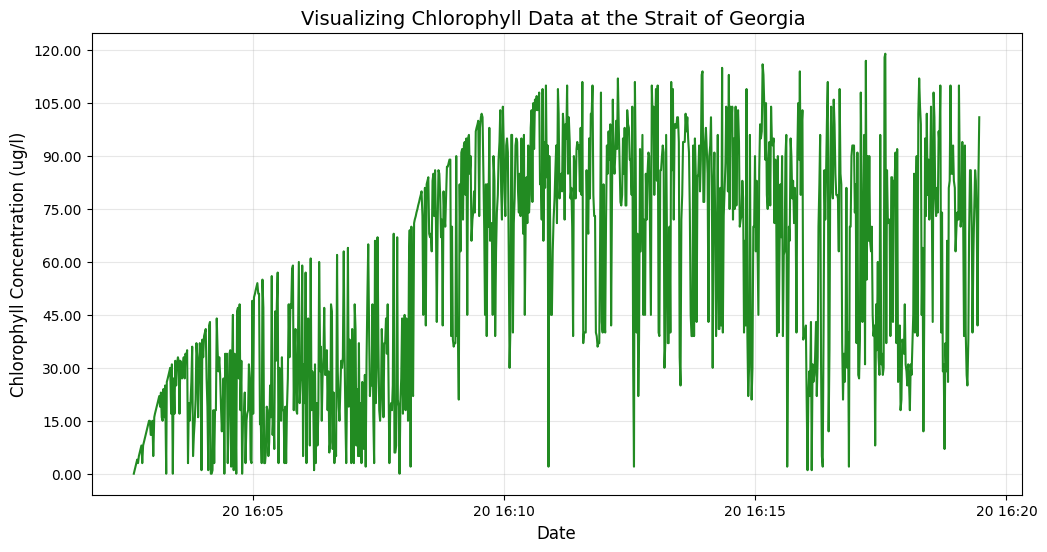

In [98]:
# To format the y-axis
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))

plt.plot(chlorophyll_df['sampleTimes'],chlorophyll_df['values'], color='forestgreen', linewidth=1.5 )

plt.title('Visualizing Chlorophyll Data at the Strait of Georgia ', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel(f'Chlorophyll Concentration ({unit_of_measure})', fontsize=12)


plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.grid(True, alpha=0.3)

plt.show()

Now that we have cleaned our axes and formatted our data, the true scale of the 2026 Spring Bloom is revealed.

What the Data Tells Us:

- Rising levels: The sensor levels gradually increased over the 20 miniute interval displaying the influx of chlorophyll.


What these means in the real world?

That's where we connect this image:
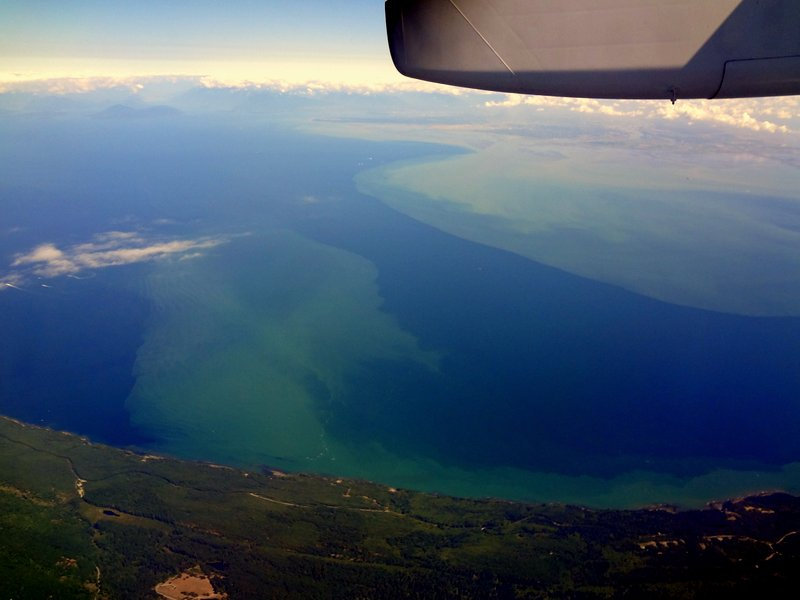

To our data!!!!

Isn't that increadible!

This is just one of the many things you can do with ONC's Open API.

I hope you enjoyed this dive into the API, and I hope you learned a lot on how to work with the Ocean Networks Canada API.